From this work we will consolidate our machine learning (ML) modeling skills by using two popular classification models to identify fraudulent credit card transactions. These models are: Decision Tree and Support Vector Machine.we will use a real dataset of credit card transactions to train each of these models. we will then use the trained model to assess if a credit card transaction is fraudulent or not.

### Objectives  

* Perform basic data preprocessing in Python   
* Model a classification task using the Scikit-Learn Python APIs   
* Train Suppport Vector Machine and Decision Tree models using Scikit-Learn   
* Run inference and assess the quality of the trained models   

<div id="Introduction">
    <h2>About work and dataset</h2>
    <br>Imagine that you work for a financial institution and part of your job is to build a model that predicts if a credit card transaction is fraudulent or not. You can model the problem as a binary classification problem. A transaction belongs to the positive class (1) if it is a fraud, otherwise it belongs to the negative class (0).
    <br>
    <br>You have access to transactions that occured over a certain period of time. The majority of the transactions are normally legitimate and only a small fraction are non-legitimate. Thus, typically you have access to a dataset that is highly unbalanced. This is also the case of the current dataset: only 492 transactions out of 284,807 are fraudulent (the positive class - the frauds - accounts for 0.172% of all transactions).
    <br>
    <br>This is a Kaggle dataset. You can find this "Credit Card Fraud Detection" dataset from the following link: <a href="https://www.kaggle.com/mlg-ulb/creditcardfraud">Credit Card Fraud Detection</a>.
<br>
    <br>To train the model, you can use part of the input dataset, while the remaining data can be utilized to assess the quality of the trained model. First, let's import the necessary libraries and download the dataset.
    <br>
</div>

In [1]:
# Import the libraries we need to use in this lab
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
dataframe = pd.read_csv('creditcard.csv')
dataframe

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df = dataframe.copy()
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Dataset Analysis

Each row in the dataset represents a credit card transaction. As shown above, each row has 31 variables. One variable (the last variable in the table above) is called Class and represents the target variable. Your objective will be to train a model that uses the other variables to predict the value of the Class variable. Let's first retrieve basic statistics about the target variable.

Note: For confidentiality reasons, the original names of most features are anonymized V1, V2 .. V28. The values of these features are the result of a PCA transformation and are numerical. The feature 'Class' is the target variable and it takes two values: 1 in case of fraud and 0 otherwise. For more information about the dataset please visit this webpage: https://www.kaggle.com/mlg-ulb/creditcardfraud.

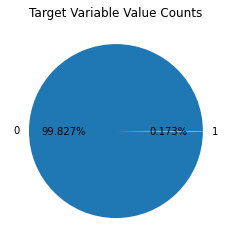

In [4]:
# get the set of distinct classes
labels = df.Class.unique()

# get the count of each class
sizes = df.Class.value_counts().values

# plot the class value counts
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

As shown above, the Class variable has two values: 0 (the credit card transaction is legitimate) and 1 (the credit card transaction is fraudulent). Thus, you need to model a binary classification problem. Moreover, the dataset is highly unbalanced, the target variable classes are not represented equally. This case requires special attention when training or when evaluating the quality of a model. One way of handing this case at train time is to bias the model to pay more attention to the samples in the minority class. The models under the current study will be configured to take into account the class weights of the samples at train/fit time.   

It is also prudent to understand which features affect the model in what way. We can visualize the effect of the different features on the model using the code below.

<AxesSubplot:>

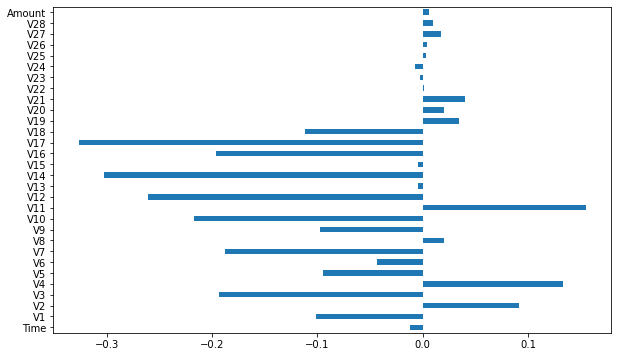

In [5]:
correlation_values = df.corr()['Class'].drop('Class')
correlation_values.plot(kind='barh', figsize=(10, 6))

This clearly shows that some features affect the output Class more than the others. For efficient modeling, we may use only the most correlated features.

### Data Preprocessing

You will now prepare the data for training. You will apply standard scaling to the input features and normalize them using $L_1$ norm for the training models to converge quickly. As seen in the data snapshot, there is a parameter called `Time` which we will not be considering for modeling. Hence, features 2 to 30 will be used as input features and feature 31, i.e. Class will be used as the target variable.

In [6]:
# standardize features by removing the mean and scaling to unit variance
df.iloc[:, 1:30] = StandardScaler().fit_transform(df.iloc[:, 1:30])
data_matrix = df.values

# X: feature matrix (for this analysis, we exclude the Time variable from the dataset)
X = data_matrix[:, 1:30]

# y: labels vector
y = data_matrix[:, 30]

# data normalization
X = normalize(X, norm="l1")

<div id="dataset_split">
    <h2>Dataset Train/Test Split</h2>
</div>


Now that the dataset is ready for building the classification models, you need to first divide the pre-processed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<div id="dt_sklearn">
    <h2>Build a Decision Tree Classifier model with Scikit-Learn</h2>
</div>


Compute the sample weights to be used as input to the train routine so that it takes into account the class imbalance present in this dataset.

In [8]:
w_train = compute_sample_weight('balanced', y_train)

Using these sample weights, we may train the Decision Tree classifier. We also make note of the time it takes for training this model to compare it against SVM, later in the lab.

In [9]:
# for reproducible output across multiple function calls, set random_state to a given integer value
dt = DecisionTreeClassifier(max_depth=4, random_state=35)

dt.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

<div id="svm_sklearn">
    <h2>Build a Support Vector Machine model with Scikit-Learn</h2>
</div>


Unlike Decision Trees, we do not need to initiate a separate sample_weight for SVMs. We can simply pass a parameter in the scikit-learn function.

In [10]:
# for reproducible output across multiple function calls, set random_state to a given integer value
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)

svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

<div id="dt_sklearn_snapml">
    <h2>Evaluate the Decision Tree Classifier Models</h2>
</div>


Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions.

In [11]:
y_pred_dt = dt.predict_proba(X_test)[:,1]

Using these probabilities, we can evaluate the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) score as a metric of model performance. The AUC-ROC score evaluates your model's ability to distinguish positive and negative classes considering all possible probability thresholds. The higher its value, the better the model is considered for separating the two classes of values.

In [12]:
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.939


<div id="svm_sklearn_snap">
    <h2>Evaluate the Support Vector Machine Models</h2>
</div>


Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions.

In [13]:
y_pred_svm = svm.decision_function(X_test)

You may now evaluate the accuracy of SVM on the test set in terms of the ROC-AUC score.

In [14]:
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

SVM ROC-AUC score: 0.986


Currently, we have used all 30 features of the dataset for training the models. Use the corr() function to find the top 6 features of the dataset to train the models on.

In [15]:
correlation_values = abs(df.corr()['Class']).drop('Class')
correlation_values = correlation_values.sort_values(ascending=False)[:6]
correlation_values

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
Name: Class, dtype: float64

Using only these 6 features, modify the input variable for training.

In [16]:
#Replace the statement defining the variable `X` with the following and run the cell again.
X = data_matrix[:,[3,10,12,14,16,17]]

__Re-normalize the 6-feature X:__

In [17]:
# Normalize the reduced feature set
X = normalize(X, norm="l1")

**Re-split:**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Re-train Decision Tree:**

In [19]:
w_train = compute_sample_weight('balanced', y_train)

dt_reduced = DecisionTreeClassifier(max_depth=4, random_state=35)
dt_reduced.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

**Re-train SVM:**

In [20]:
svm_reduced = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
svm_reduced.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

**Evaluate both and compare:**

In [21]:
# Decision Tree on 6 features
y_pred_dt_reduced = dt_reduced.predict_proba(X_test)[:, 1]
roc_auc_dt_reduced = roc_auc_score(y_test, y_pred_dt_reduced)
print('Decision Tree (6 features) ROC-AUC score : {0:.3f}'.format(roc_auc_dt_reduced))

# SVM on 6 features
y_pred_svm_reduced = svm_reduced.decision_function(X_test)
roc_auc_svm_reduced = roc_auc_score(y_test, y_pred_svm_reduced)
print('SVM (6 features) ROC-AUC score : {0:.3f}'.format(roc_auc_svm_reduced))

# Comparison
print('\n--- Comparison ---')
print(f'Decision Tree  | All 29 features: {roc_auc_dt:.3f} | Top 6 features: {roc_auc_dt_reduced:.3f}')
print(f'SVM            | All 29 features: {roc_auc_svm:.3f} | Top 6 features: {roc_auc_svm_reduced:.3f}')

Decision Tree (6 features) ROC-AUC score : 0.952
SVM (6 features) ROC-AUC score : 0.937

--- Comparison ---
Decision Tree  | All 29 features: 0.939 | Top 6 features: 0.952
SVM            | All 29 features: 0.986 | Top 6 features: 0.937


**Decision Tree** actually improved when going from 29 features to just 6 from 0.939 → 0.952. This is a healthy sign. With all  29 features, the tree was likely picking up some noise. The top 6 correlated features gave it a cleaner, more focused signal,   
which boosted its fraud detection ability.   
   
**SVM dropped** from 0.986 → 0.937 with 6 features. This makes sense too SVM is a margin-based model that benefits from high-dimensional space. Removing 23 features took away useful separability that the hyperplane was relying on, so its performance  
dipped.    
*`Feature selection`* helps simpler models like Decision Trees by reducing noise, but can hurt powerful models like SVM that leverage high-dimensional geometry. The best model overall remains SVM with all 29 features at 0.986 ROC-AUC.

__Confusion Matrix (Decision Tree)__

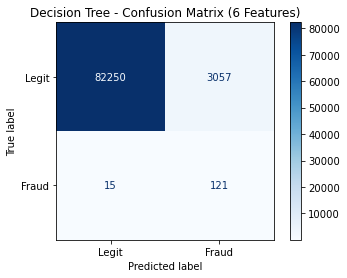

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_dt_labels = dt_reduced.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Decision Tree - Confusion Matrix (6 Features)')
plt.show()

__Confusion Matrix (SVM)__

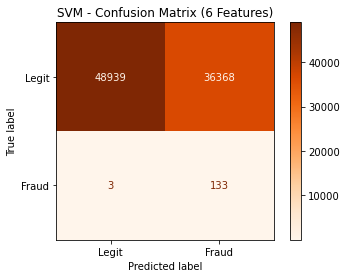

In [23]:
y_pred_svm_labels = svm_reduced.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Oranges')
plt.title('SVM - Confusion Matrix (6 Features)')
plt.show()

__Precision, Recall, F1-Score__

In [24]:
from sklearn.metrics import classification_report

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt_labels, target_names=['Legit', 'Fraud']))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm_labels, target_names=['Legit', 'Fraud']))

=== Decision Tree ===
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     85307
       Fraud       0.04      0.89      0.07       136

    accuracy                           0.96     85443
   macro avg       0.52      0.93      0.53     85443
weighted avg       1.00      0.96      0.98     85443

=== SVM ===
              precision    recall  f1-score   support

       Legit       1.00      0.57      0.73     85307
       Fraud       0.00      0.98      0.01       136

    accuracy                           0.57     85443
   macro avg       0.50      0.78      0.37     85443
weighted avg       1.00      0.57      0.73     85443



__Precision-Recall Curve__

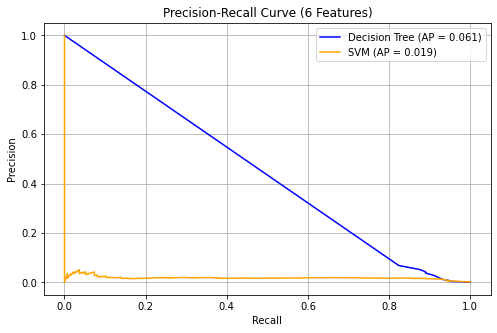

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Decision Tree
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_dt_reduced)
ap_dt = average_precision_score(y_test, y_pred_dt_reduced)

# SVM
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_pred_svm_reduced)
ap_svm = average_precision_score(y_test, y_pred_svm_reduced)

plt.figure(figsize=(8, 5))
plt.plot(recall_dt, precision_dt, label=f'Decision Tree (AP = {ap_dt:.3f})', color='blue')
plt.plot(recall_svm, precision_svm, label=f'SVM (AP = {ap_svm:.3f})', color='orange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (6 Features)')
plt.legend()
plt.grid(True)
plt.show()

__Visualize the Decision Tree__

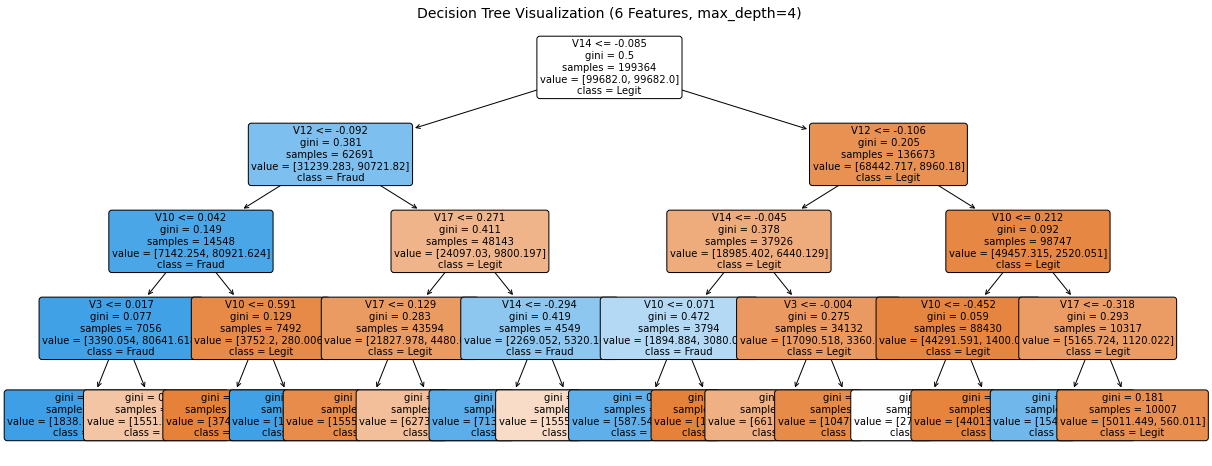

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt_reduced,
    feature_names=['V3', 'V10', 'V12', 'V14', 'V16', 'V17'],
    class_names=['Legit', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Visualization (6 Features, max_depth=4)', fontsize=14)
plt.show()

 __Feature Importance__

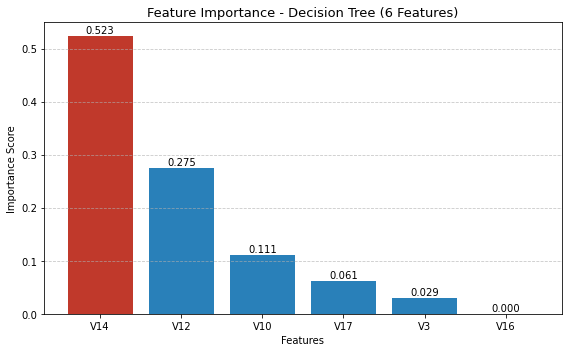

Feature Importance Ranking:
  1. V14 : 0.5231
  2. V12 : 0.2749
  3. V10 : 0.1114
  4. V17 : 0.0612
  5. V3 : 0.0294
  6. V16 : 0.0000


In [27]:
import numpy as np
feature_names = ['V3', 'V10', 'V12', 'V14', 'V16', 'V17']
importances = dt_reduced.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importance = importances[indices]

plt.figure(figsize=(8, 5))
bars = plt.bar(sorted_features, sorted_importance, color=['#c0392b' if i == 0 else '#2980b9' for i in range(len(sorted_features))])
plt.title('Feature Importance - Decision Tree (6 Features)', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar, val in zip(bars, sorted_importance):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print ranked summary
print("Feature Importance Ranking:")
for i, (f, v) in enumerate(zip(sorted_features, sorted_importance)):
    print(f"  {i+1}. {f} : {v:.4f}")

`V14` dominates at 0.523 — more than half the model's decisions are driven by this single feature. This perfectly matches the tree visualization where `V14` was the root split. `V12` at 0.275 is the second most important. Together they account for ~80% of the model's decision-making. `V16` contributes literally 0.000 — it was selected by correlation but the tree never actually used it, which is a great insight to mention.